#### 🔌 Importing core dependencies | 🏗️ XTALLET

In [1]:
from langchain_mcp_adapters.client import MultiServerMCPClient
from langgraph.graph import StateGraph, MessagesState, START
from langgraph.prebuilt import ToolNode, tools_condition

#### 🧠 Initializing the chat model | 🏗️ XTALLET

In [2]:
from langchain.chat_models import init_chat_model
model = init_chat_model("openai:gpt-4.1")

#### 🔗 Connecting to the MCP server | 🏗️ XTALLET

In [3]:
client = MultiServerMCPClient(
    {
        "news": {
            "command": "python",
            "args": ["./activity1_mcp_server.py"],
            "transport": "stdio",
        }
    }
)

#### 🛠️ Loading available tools from the MCP server | 🏗️ XTALLET

In [4]:
tools = await client.get_tools()

#### 📤 Printing retrieved tools | 🏗️ XTALLET

In [5]:
tools

[StructuredTool(name='get_top_headlines', description='Get top headlines from News API for a specific country and optional category', args_schema={'properties': {'country': {'default': 'us', 'title': 'Country', 'type': 'string'}, 'category': {'default': None, 'title': 'Category', 'type': 'string'}, 'page_size': {'default': 10, 'title': 'Page Size', 'type': 'integer'}}, 'title': 'get_top_headlinesArguments', 'type': 'object'}, response_format='content_and_artifact', coroutine=<function convert_mcp_tool_to_langchain_tool.<locals>.call_tool at 0x7c538413ba60>),
 StructuredTool(name='search_news', description='Search for news articles based on a query', args_schema={'properties': {'query': {'title': 'Query', 'type': 'string'}, 'language': {'default': 'en', 'title': 'Language', 'type': 'string'}, 'sort_by': {'default': 'publishedAt', 'title': 'Sort By', 'type': 'string'}, 'page_size': {'default': 10, 'title': 'Page Size', 'type': 'integer'}}, 'required': ['query'], 'title': 'search_newsArgu

#### 🤖 Defining the model invocation function | 🏗️ XTALLET

In [6]:
def call_model(state: MessagesState):
    response = model.bind_tools(tools).invoke(state["messages"])
    return {"messages": response}

#### 🧱 Building the graph and adding nodes | 🏗️ XTALLET

In [7]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_node("tools", ToolNode(tools))

#### 🔀 Defining edges and conditional flow | 🏗️ XTALLET

In [8]:
builder.add_edge(START, "call_model")
builder.add_conditional_edges("call_model", tools_condition)
builder.add_edge("tools", "call_model")

#### 🚧 Compiling the state graph | 🏗️ XTALLET

In [9]:
graph = builder.compile()

#### 📋 Displaying the compiled graph object | 🏗️ XTALLET

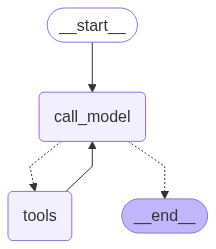

In [10]:
graph

#### 📨 Sending initial query to the graph | 🏗️ XTALLET

In [11]:
result_1 = await graph.ainvoke({"messages": "show me the top headlines from the US in technology"})

#### 🖨️ Printing the latest AI response content | 🏗️ XTALLET

In [12]:
print(result_1["messages"][-1].content)

Here are the top technology headlines in the US right now:

1. "Still live: One of the best prices ever on 24GB M4 Mac mini at $699 + 48GB and 64GB models at $200 off" - 9to5Toys  
2. "NotebookLM rolls out Video Overviews, Studio redesign, and more" - 9to5Google  
3. "A Single Poisoned Document Could Leak ‘Secret’ Data Via ChatGPT" - WIRED  
4. "Guilty Gear Strive Producer On Lucy, Upcoming Balance Changes, and Strive 2.00 | Evo 2025" - IGN  
5. "CoD Season 5 Patch Notes: BO6 And Warzone Adds Weapon Balancing And Stadium Event" - GameSpot  

Would you like a summary or more details on any of these headlines?


#### 📦 Printing the full response object | 🏗️ XTALLET

In [13]:
print(result_1)

{'messages': [HumanMessage(content='show me the top headlines from the US in technology', additional_kwargs={}, response_metadata={}, id='0503cae8-574c-4c83-8b51-9be64164b278'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_JDHFvjaH1ImbGME6xe7Xbe9B', 'function': {'arguments': '{"country":"us","category":"technology","page_size":5}', 'name': 'get_top_headlines'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 189, 'total_tokens': 214, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_51e1070cf2', 'id': 'chatcmpl-C2DgMXv9Y8sKyNbHtNvYs9VQXVcIt', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--a9dc833b-fb98-430c-b956-0ce237de0430-0', tool_calls=[{

#### 🔍 Extracting tools used and printing final response | 🏗️ XTALLET

In [14]:
# Extract messages
messages = result_1["messages"]

# Detect used tools
tool_calls = [
    call["name"]
    for msg in messages
    if hasattr(msg, "tool_calls") and msg.tool_calls
    for call in msg.tool_calls
]

# Show used tools with emoji
if tool_calls:
    unique_tools = ", ".join(set(tool_calls))
    print(f"🛠️ Tools used: {unique_tools}")
else:
    print("💬 No tools were used.")

# Show final model response (last AIMessage with content)
final_response = next(
    (msg.content for msg in reversed(messages) if msg.type == "ai" and msg.content.strip()), 
    None
)
if final_response:
    print(f"\n✅ Final response:\n{final_response}")
else:
    print("\n⚠️ No final response from the model.")

🛠️ Tools used: get_top_headlines

✅ Final response:
Here are the top technology headlines in the US right now:

1. "Still live: One of the best prices ever on 24GB M4 Mac mini at $699 + 48GB and 64GB models at $200 off" - 9to5Toys  
2. "NotebookLM rolls out Video Overviews, Studio redesign, and more" - 9to5Google  
3. "A Single Poisoned Document Could Leak ‘Secret’ Data Via ChatGPT" - WIRED  
4. "Guilty Gear Strive Producer On Lucy, Upcoming Balance Changes, and Strive 2.00 | Evo 2025" - IGN  
5. "CoD Season 5 Patch Notes: BO6 And Warzone Adds Weapon Balancing And Stadium Event" - GameSpot  

Would you like a summary or more details on any of these headlines?


#### 📨 Sending a second query with different parameters | 🏗️ XTALLET

In [15]:
result_2 = await graph.ainvoke({"messages": "search news about artificial intelligence in Spanish"})

#### 🔍 Extracting tools used and printing final response (second query) | 🏗️ XTALLET

In [16]:
# Extract messages
messages = result_2["messages"]

# Detect used tools
tool_calls = [
    call["name"]
    for msg in messages
    if hasattr(msg, "tool_calls") and msg.tool_calls
    for call in msg.tool_calls
]

# Show used tools with emoji
if tool_calls:
    unique_tools = ", ".join(set(tool_calls))
    print(f"🛠️ Tools used: {unique_tools}")
else:
    print("💬 No tools were used.")

# Show final model response (last AIMessage with content)
final_response = next(
    (msg.content for msg in reversed(messages) if msg.type == "ai" and msg.content.strip()), 
    None
)
if final_response:
    print(f"\n✅ Final response:\n{final_response}")
else:
    print("\n⚠️ No final response from the model.")


🛠️ Tools used: search_news

✅ Final response:
Aquí tienes las 10 noticias más recientes sobre inteligencia artificial en español:

1. Ulf Kristersson, primer ministro de Suecia, desata la polémica: "Uso ChatGPT para obtener segundas opiniones". El político ha asegurado que usa la IA de OpenAI para tomar decisiones de gobierno.
2. ¿Está realmente la IA de Google transformando la búsqueda y mejorando la calidad de los clics orgánicos? La IA ha comenzado a moldear la experiencia de búsqueda de Google.
3. GPT-5 aterriza en GitHub Models: lo que cambia para desarrolladores y empresas. Es el modelo más avanzado de OpenAI hasta la fecha.
4. Red.es ejecutó 815 millones durante el primer semestre, un 61% del presupuesto previsto para 2025, impulsando proyectos de transformación digital e IA.
5. IA+Igual lanza un Libro Blanco para desarrollar un estándar de certificación de IA en el trabajo y evitar sesgos.
6. Xpeng presenta su nuevo buque insignia, el sedán P7, con tecnologías avanzadas de IA.


#### 📨 Querying news sources for the UK | 🏗️ XTALLET

In [17]:
result_3 = await graph.ainvoke({"messages": "what are the news sources available in the UK?"})

#### 🔍 Extracting tools used and printing final response (UK news sources) | 🏗️ XTALLET

In [18]:
# Extract messages
messages = result_3["messages"]

# Detect used tools
tool_calls = [
    call["name"]
    for msg in messages
    if hasattr(msg, "tool_calls") and msg.tool_calls
    for call in msg.tool_calls
]

# Show used tools with emoji
if tool_calls:
    unique_tools = ", ".join(set(tool_calls))
    print(f"🛠️ Tools used: {unique_tools}")
else:
    print("💬 No tools were used.")

# Show final model response (last AIMessage with content)
final_response = next(
    (msg.content for msg in reversed(messages) if msg.type == "ai" and msg.content.strip()), 
    None
)
if final_response:
    print(f"\n✅ Final response:\n{final_response}")
else:
    print("\n⚠️ No final response from the model.")

🛠️ Tools used: get_news_sources

✅ Final response:
Here are some news sources available in the UK:

1. BBC News – Up-to-the-minute news, breaking news, video, audio, and feature stories.
2. BBC Sport – Live sports coverage, results, video, audio, and analysis.
3. FourFourTwo – Latest football news, features, and tactical analysis.
4. Google News (UK) – Aggregated news from multiple global sources with a UK focus.
5. Independent – National news with in-depth features and online access.
6. MTV News (UK) – Celebrity news, interviews, and music world updates.
7. TalkSport – Live Premier League coverage and breaking sports news.
8. The Lad Bible – News and entertainment for young adults.
9. The Sport Bible – Sports news and fan community.

If you need information on a particular category or a full list, let me know!
